In [1]:
import numpy as np
import matplotlib.pyplot as plt

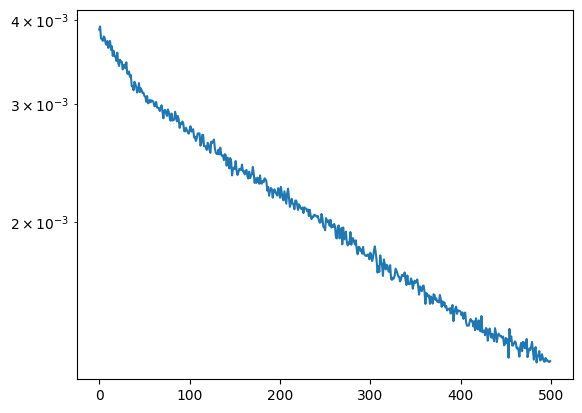

In [2]:
t = np.genfromtxt('checkpoints/losses.txt')

plt.plot(t)
plt.yscale('log')
# plt.xlim(0, 50)

In [3]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import jax
import jax.numpy as jnp

from train import F_true, TRAIN_BOUNDS

# F_true takes a single point x = (t, drho, dp, du) and returns the 3-vector
# face flux (mass, momentum, energy). F(t) = t * f(u*(0)) so we use t=1 to
# read off the instantaneous flux.
F_batch = jax.jit(jax.vmap(F_true))

N = 80
# Restrict slice grids to the training domain (TRAIN_BOUNDS from train.py)
# so we visualize the model on points it was actually trained on.
(t_lo,    t_hi),    \
(drho_lo, drho_hi), \
(dp_lo,   dp_hi),   \
(du_lo,   du_hi) = [tuple(b) for b in TRAIN_BOUNDS.tolist()]

drho_grid = jnp.linspace(drho_lo, drho_hi, N)
dp_grid   = jnp.linspace(dp_lo,   dp_hi,   N)
du_grid   = jnp.linspace(du_lo,   du_hi,   N)

# t_eval = t_hi
t_eval = 0.5


def eval_slice(A, B, C):
    pts = jnp.stack([jnp.full_like(A, t_eval), A, B, C], axis=-1).reshape(-1, 4)
    return F_batch(pts).reshape(A.shape + (3,))


# Three 2-D slices through the origin of the held-out delta.
DRHO, DP = jnp.meshgrid(drho_grid, dp_grid, indexing="ij")
F_drho_dp = eval_slice(DRHO, DP, jnp.zeros_like(DRHO))

DRHO, DU = jnp.meshgrid(drho_grid, du_grid, indexing="ij")
F_drho_du = eval_slice(DRHO, jnp.zeros_like(DRHO), DU)

DP, DU = jnp.meshgrid(dp_grid, du_grid, indexing="ij")
F_dp_du = eval_slice(jnp.zeros_like(DP), DP, DU)

print("flux shapes:", F_drho_dp.shape, F_drho_du.shape, F_dp_du.shape)
print(f"slice plane evaluated at t = {t_eval}")
print(
    f"training domain: drho in [{drho_lo}, {drho_hi}], "
    f"dp in [{dp_lo}, {dp_hi}], du in [{du_lo}, {du_hi}]"
)

flux shapes: (80, 80, 3) (80, 80, 3) (80, 80, 3)
slice plane evaluated at t = 0.5
training domain: drho in [-0.8, 0.8], dp in [-0.8, 0.8], du in [-1.0, 0.4]


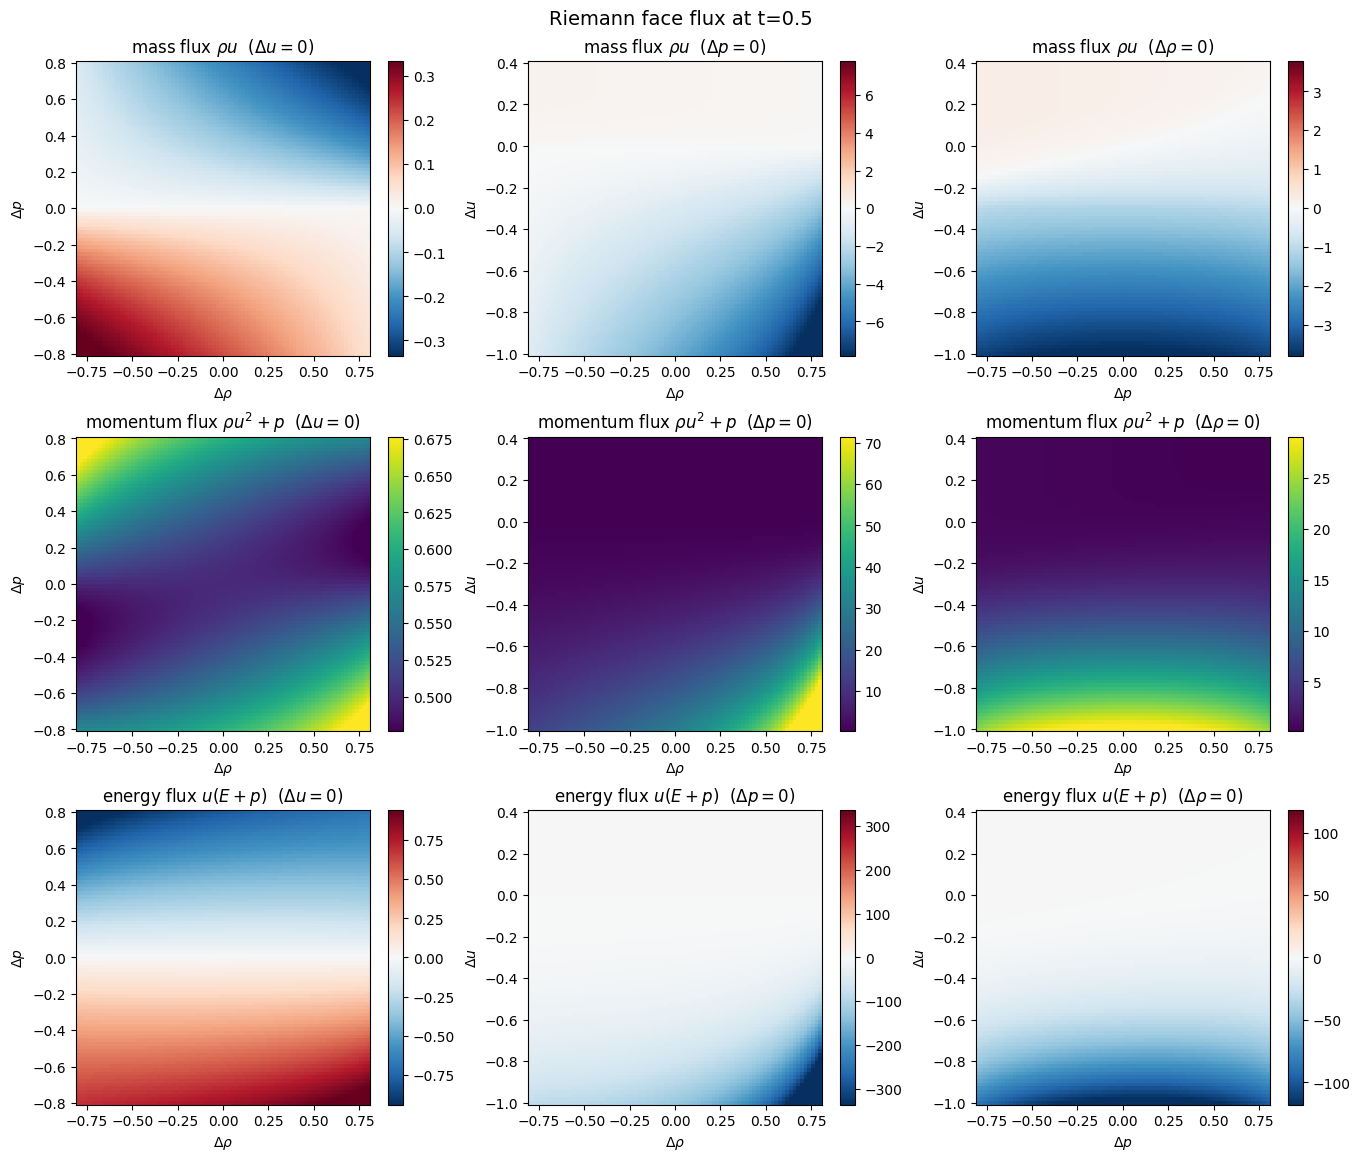

In [4]:
from matplotlib.colors import TwoSlopeNorm

component_names = [
    r"mass flux $\rho u$",
    r"momentum flux $\rho u^2 + p$",
    r"energy flux $u(E + p)$",
]
slices = [
    ("$\\Delta\\rho$", "$\\Delta p$", drho_grid, dp_grid, F_drho_dp, "$\\Delta u = 0$"),
    ("$\\Delta\\rho$", "$\\Delta u$", drho_grid, du_grid, F_drho_du, "$\\Delta p = 0$"),
    ("$\\Delta p$",   "$\\Delta u$", dp_grid,   du_grid, F_dp_du,   "$\\Delta\\rho = 0$"),
]

fig, axes = plt.subplots(3, 3, figsize=(13.5, 11.5), constrained_layout=True)
for i, name in enumerate(component_names):
    for j, (xn, yn, xg, yg, F, fixed) in enumerate(slices):
        ax = axes[i, j]
        z = np.asarray(F[..., i]).T  # transpose so first arg is on x-axis
        finite = z[np.isfinite(z)]
        if i == 1:  # momentum flux is positive (rho*u^2 + p > 0), use a sequential cmap
            vmin = np.percentile(finite, 1)
            vmax = np.percentile(finite, 99)
            im = ax.pcolormesh(
                np.asarray(xg), np.asarray(yg), z,
                cmap="viridis", vmin=vmin, vmax=vmax, shading="auto",
            )
        else:  # mass / energy fluxes change sign, center the colormap at 0
            vmax = np.percentile(np.abs(finite), 99)
            norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
            im = ax.pcolormesh(
                np.asarray(xg), np.asarray(yg), z,
                cmap="RdBu_r", norm=norm, shading="auto",
            )
        fig.colorbar(im, ax=ax)
        ax.set_xlabel(xn)
        ax.set_ylabel(yn)
        ax.set_title(f"{name}  ({fixed})")

fig.suptitle(f"Riemann face flux at t={t_eval}", fontsize=14)
plt.show()

In [5]:
from checkpoint import load_latest
from train import F_pred, _build_model

ckpt_dir = Path.cwd() / "checkpoints"
F_net = load_latest(ckpt_dir, _build_model)

ckpts = sorted(ckpt_dir.glob("F_net_*.msgpack"))
print(f"loaded {ckpts[-1].name} ({len(ckpts)} checkpoints total)")

# Batched prediction at a single time slice. F_pred(F_net, x) = x[0] * F_net(x),
# i.e. the integrated face flux at time x[0]. We'll evaluate it on the same
# slice grids built above so we can compare against F_drho_dp / F_drho_du /
# F_dp_du from the previous cell.
F_pred_batch = jax.jit(jax.vmap(lambda r: F_pred(F_net, r)))


def pred_slice(A, B, C):
    pts = jnp.stack([jnp.full_like(A, t_eval), A, B, C], axis=-1).reshape(-1, 4)
    return F_pred_batch(pts).reshape(A.shape + (3,))


DRHO, DP = jnp.meshgrid(drho_grid, dp_grid, indexing="ij")
P_drho_dp = pred_slice(DRHO, DP, jnp.zeros_like(DRHO))

DRHO, DU = jnp.meshgrid(drho_grid, du_grid, indexing="ij")
P_drho_du = pred_slice(DRHO, jnp.zeros_like(DRHO), DU)

DP, DU = jnp.meshgrid(dp_grid, du_grid, indexing="ij")
P_dp_du = pred_slice(jnp.zeros_like(DP), DP, DU)

print("pred shapes:", P_drho_dp.shape, P_drho_du.shape, P_dp_du.shape)

loaded F_net_003800.msgpack (38 checkpoints total)
pred shapes: (80, 80, 3) (80, 80, 3) (80, 80, 3)


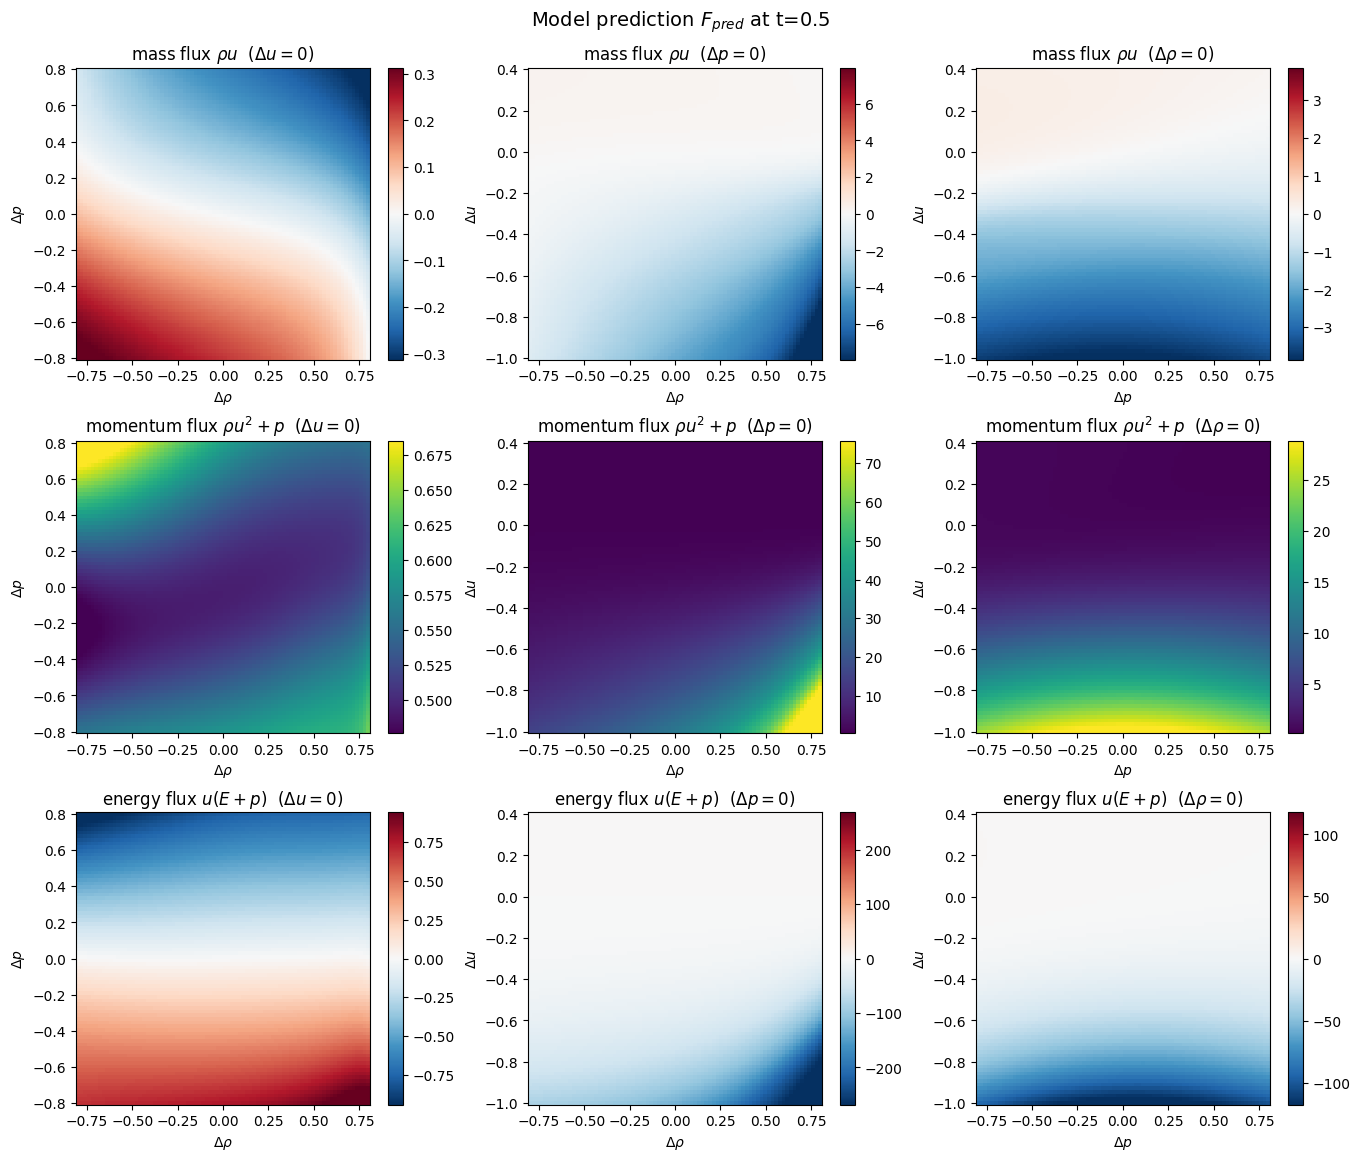

In [6]:
pred_slices = [
    ("$\\Delta\\rho$", "$\\Delta p$", drho_grid, dp_grid, P_drho_dp, "$\\Delta u = 0$"),
    ("$\\Delta\\rho$", "$\\Delta u$", drho_grid, du_grid, P_drho_du, "$\\Delta p = 0$"),
    ("$\\Delta p$",   "$\\Delta u$", dp_grid,   du_grid, P_dp_du,   "$\\Delta\\rho = 0$"),
]

fig, axes = plt.subplots(3, 3, figsize=(13.5, 11.5), constrained_layout=True)
for i, name in enumerate(component_names):
    for j, (xn, yn, xg, yg, P, fixed) in enumerate(pred_slices):
        ax = axes[i, j]
        z = np.asarray(P[..., i]).T
        finite = z[np.isfinite(z)]
        if i == 1:
            vmin = np.percentile(finite, 1)
            vmax = np.percentile(finite, 99)
            im = ax.pcolormesh(
                np.asarray(xg), np.asarray(yg), z,
                cmap="viridis", vmin=vmin, vmax=vmax, shading="auto",
            )
        else:
            vmax = np.percentile(np.abs(finite), 99)
            norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
            im = ax.pcolormesh(
                np.asarray(xg), np.asarray(yg), z,
                cmap="RdBu_r", norm=norm, shading="auto",
            )
        fig.colorbar(im, ax=ax)
        ax.set_xlabel(xn)
        ax.set_ylabel(yn)
        ax.set_title(f"{name}  ({fixed})")

fig.suptitle(f"Model prediction $F_{{pred}}$ at t={t_eval}", fontsize=14)
plt.show()

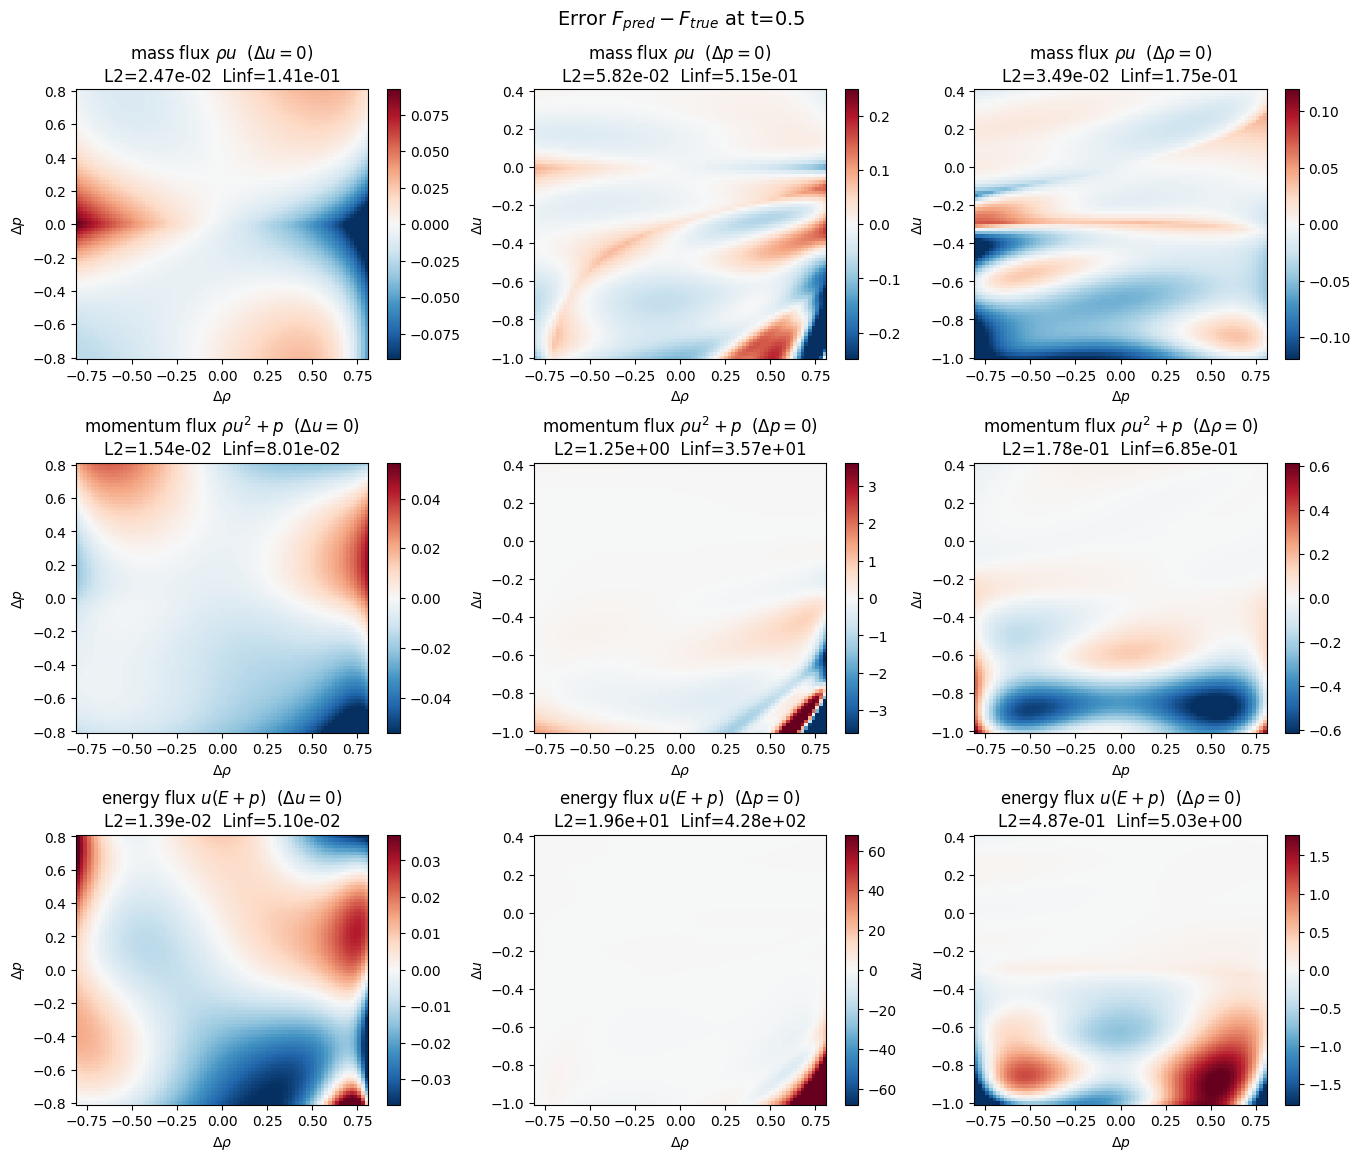

In [7]:
err_slices = [
    ("$\\Delta\\rho$", "$\\Delta p$", drho_grid, dp_grid, P_drho_dp - F_drho_dp, "$\\Delta u = 0$"),
    ("$\\Delta\\rho$", "$\\Delta u$", drho_grid, du_grid, P_drho_du - F_drho_du, "$\\Delta p = 0$"),
    ("$\\Delta p$",   "$\\Delta u$", dp_grid,   du_grid, P_dp_du   - F_dp_du,   "$\\Delta\\rho = 0$"),
]

fig, axes = plt.subplots(3, 3, figsize=(13.5, 11.5), constrained_layout=True)
for i, name in enumerate(component_names):
    for j, (xn, yn, xg, yg, E, fixed) in enumerate(err_slices):
        ax = axes[i, j]
        z = np.asarray(E[..., i]).T
        finite = z[np.isfinite(z)]
        vmax = np.percentile(np.abs(finite), 99) if finite.size else 1.0
        vmax = max(vmax, 1e-12)
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
        im = ax.pcolormesh(
            np.asarray(xg), np.asarray(yg), z,
            cmap="RdBu_r", norm=norm, shading="auto",
        )
        fig.colorbar(im, ax=ax)
        ax.set_xlabel(xn)
        ax.set_ylabel(yn)
        l2 = float(np.sqrt(np.mean(finite**2))) if finite.size else float("nan")
        linf = float(np.max(np.abs(finite))) if finite.size else float("nan")
        ax.set_title(f"{name}  ({fixed})\nL2={l2:.2e}  Linf={linf:.2e}")

fig.suptitle(f"Error $F_{{pred}} - F_{{true}}$ at t={t_eval}", fontsize=14)
plt.show()

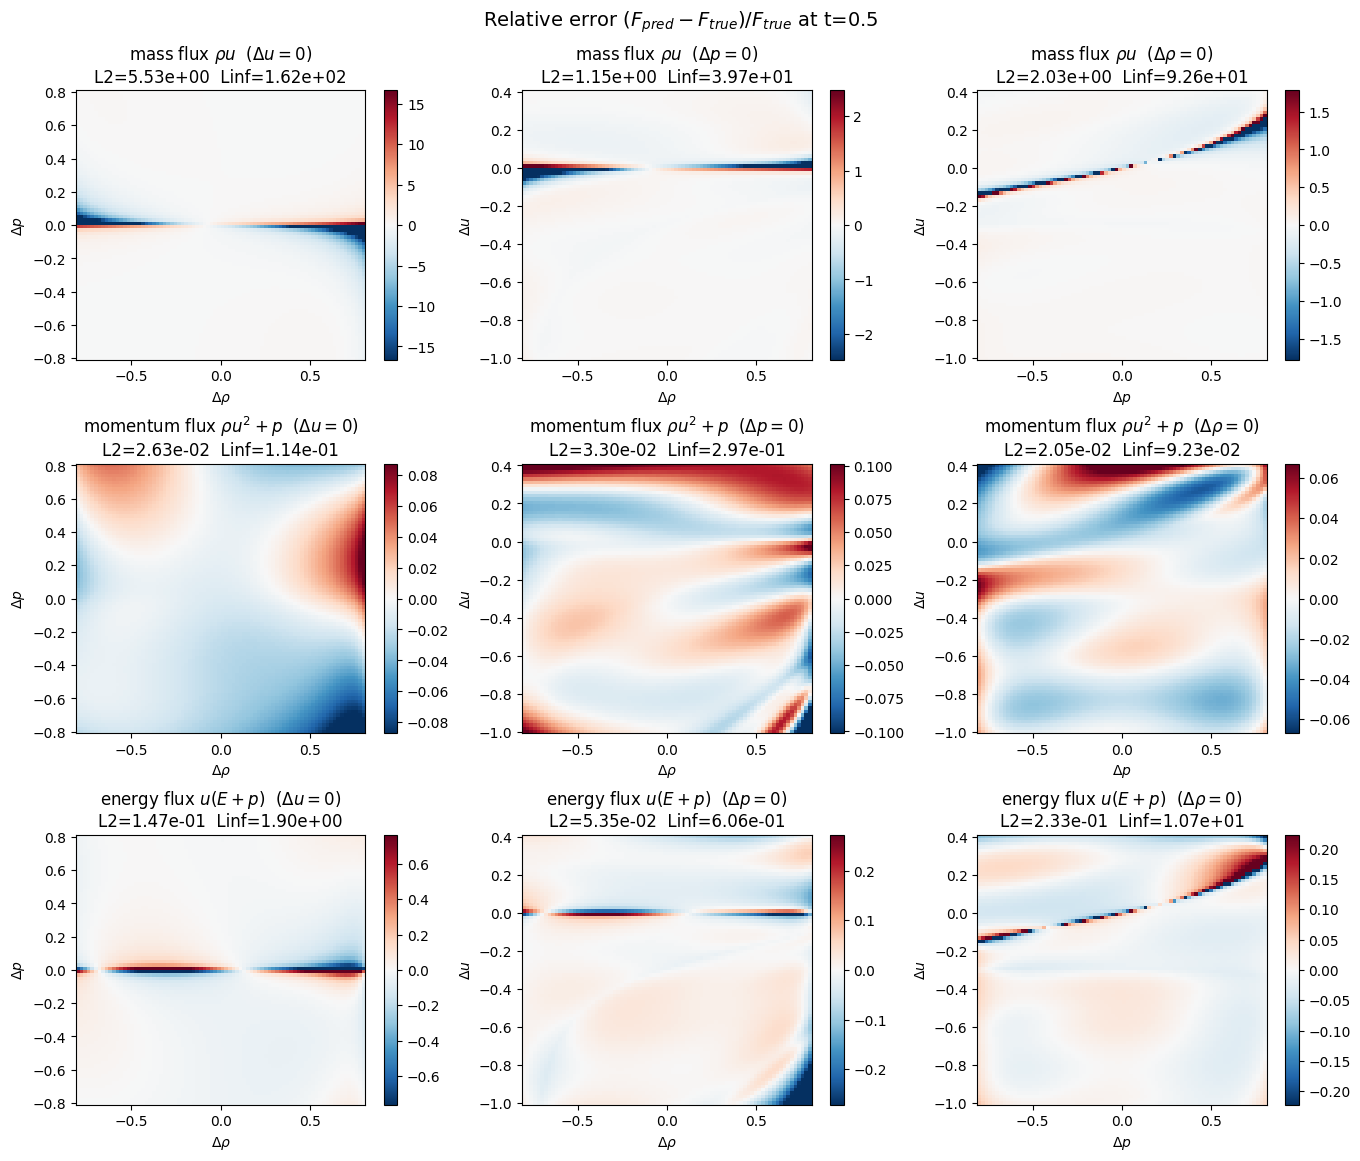

In [8]:
err_slices = [
    ("$\\Delta\\rho$", "$\\Delta p$", drho_grid, dp_grid, (P_drho_dp - F_drho_dp)/F_drho_dp, "$\\Delta u = 0$"),
    ("$\\Delta\\rho$", "$\\Delta u$", drho_grid, du_grid, (P_drho_du - F_drho_du)/F_drho_du, "$\\Delta p = 0$"),
    ("$\\Delta p$",   "$\\Delta u$", dp_grid,   du_grid, (P_dp_du   - F_dp_du)/F_dp_du,   "$\\Delta\\rho = 0$"),
]

fig, axes = plt.subplots(3, 3, figsize=(13.5, 11.5), constrained_layout=True)
for i, name in enumerate(component_names):
    for j, (xn, yn, xg, yg, E, fixed) in enumerate(err_slices):
        ax = axes[i, j]
        z = np.asarray(E[..., i]).T
        finite = z[np.isfinite(z)]
        vmax = np.percentile(np.abs(finite), 99) if finite.size else 1.0
        vmax = max(vmax, 1e-12)
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
        im = ax.pcolormesh(
            np.asarray(xg), np.asarray(yg), z,
            cmap="RdBu_r", norm=norm, shading="auto",
        )
        fig.colorbar(im, ax=ax)
        ax.set_xlabel(xn)
        ax.set_ylabel(yn)
        l2 = float(np.sqrt(np.mean(finite**2))) if finite.size else float("nan")
        linf = float(np.max(np.abs(finite))) if finite.size else float("nan")
        ax.set_title(f"{name}  ({fixed})\nL2={l2:.2e}  Linf={linf:.2e}")

fig.suptitle(f"Relative error $(F_{{pred}} - F_{{true}})/F_{{true}}$ at t={t_eval}", fontsize=14)
plt.show()

In [9]:
from jax import random as jr

from evaluate import draw_rect, evaluate_all, draw_small_jumps

# Holdout metrics restricted to the training domain (TRAIN_BOUNDS) plus a
# small-jump regime that lives well inside it.
key = jr.PRNGKey(123)
k_train, k_sj = jr.split(key)

regimes = {
    "train_domain": draw_rect(k_train, 2**17, TRAIN_BOUNDS),
    "small_jump":   draw_small_jumps(k_sj, 2**17),
}

metrics = evaluate_all(F_net, F_pred_fn=F_pred, F_true_fn=F_true, regimes=regimes)

for label in regimes:
    print(
        f"{label:>13s}  "
        f"L2={metrics[f'l2_{label}']:.3e} (rel {metrics[f'rel_l2_{label}']:.3e})  "
        f"Linf={metrics[f'linf_{label}']:.3e} (rel {metrics[f'rel_linf_{label}']:.3e})"
    )

 train_domain  L2=1.252e+01 (rel 2.644e-01)  Linf=9.731e+02 (rel 3.909e+03)
   small_jump  L2=5.689e-03 (rel 1.698e-02)  Linf=1.459e-02 (rel 4.314e+04)
